# 02_eda

EduPredict — generated notebook. All statistics and results must be calculated from the actual dataset.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/StudentPerformanceFactors.csv")
Path("../outputs/figures").mkdir(parents=True, exist_ok=True)


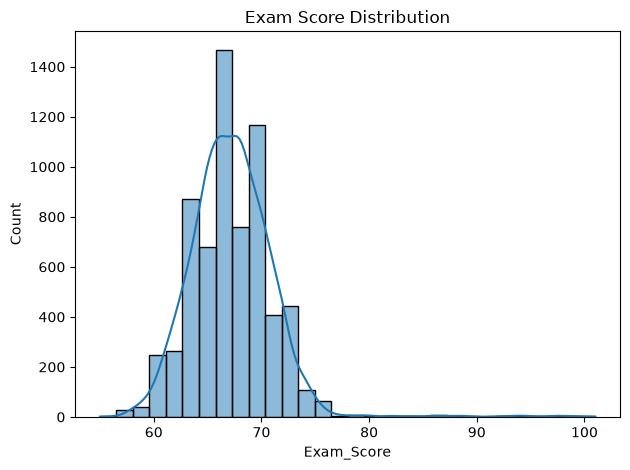

In [2]:
sns.histplot(df["Exam_Score"], bins=30, kde=True)
plt.title("Exam Score Distribution")
plt.tight_layout()
plt.savefig("../outputs/figures/target_distribution.png", dpi=150)
plt.show()


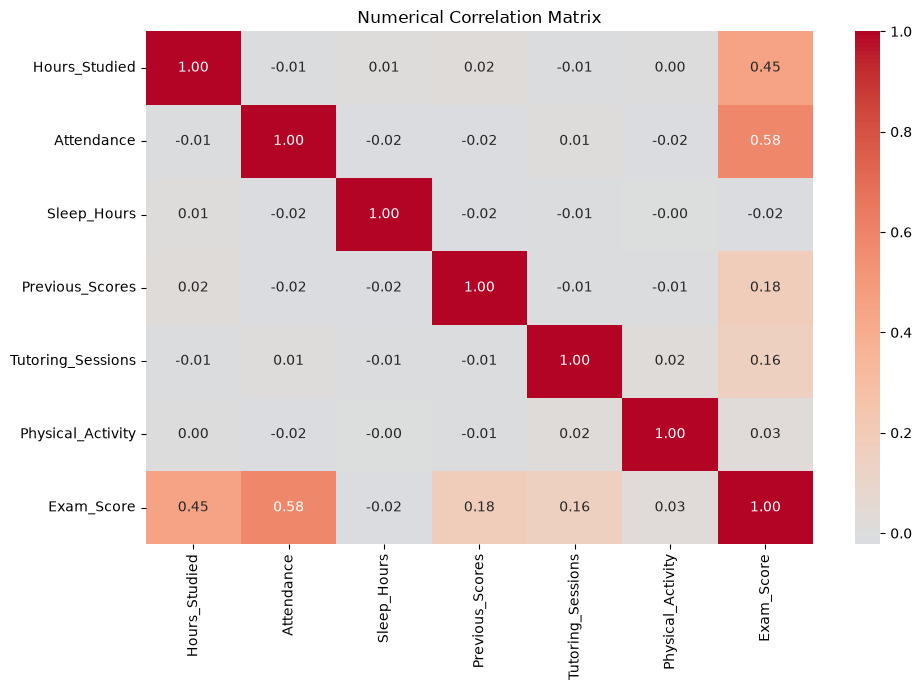

In [3]:
numeric = df.select_dtypes(include="number")
plt.figure(figsize=(10,7))
sns.heatmap(numeric.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Numerical Correlation Matrix")
plt.tight_layout()
plt.savefig("../outputs/figures/correlation_heatmap.png", dpi=150)
plt.show()


In [25]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

display(
    missing_summary[
        missing_summary["Missing_Count"] > 0
    ].sort_values(
        "Missing_Count",
        ascending=False
    )
)

,Missing_Count,Missing_Percentage
Parental_Education_Level,90,1.36
Teacher_Quality,78,1.18
Distance_from_Home,67,1.01


In [26]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [27]:
print("Exam Score statistics:")
print(df["Exam_Score"].describe())

print("\nScores above 100:")
print(df[df["Exam_Score"] > 100][["Exam_Score"]])

Exam Score statistics:
count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64

Scores above 100:
      Exam_Score
1525         101


In [28]:
df_clean = df[df["Exam_Score"].between(0, 100)].copy()

print("Original shape:", df.shape)
print("Cleaned modeling shape:", df_clean.shape)
print("Removed rows:", len(df) - len(df_clean))

Original shape: (6607, 20)
Cleaned modeling shape: (6606, 20)
Removed rows: 1


In [31]:
target_correlations = (
    df_clean[numeric_cols]
    .corr()["Exam_Score"]
    .drop("Exam_Score")
    .sort_values(
        key=abs,
        ascending=False
    )
)

print(target_correlations)

Attendance           0.582458
Hours_Studied        0.446514
Previous_Scores      0.174461
Tutoring_Sessions    0.153754
Physical_Activity    0.027943
Sleep_Hours         -0.016194
Name: Exam_Score, dtype: float64


In [32]:
categorical_cols = df_clean.select_dtypes(
    include=["object", "str"]
).columns

for col in categorical_cols:

    print("\n" + "=" * 60)
    print(col)

    result = (
        df_clean.groupby(
            col,
            dropna=False
        )["Exam_Score"]
        .agg(["count", "mean", "median"])
        .sort_values(
            "mean",
            ascending=False
        )
    )

    display(result)


Parental_Involvement


,count,mean,median
Parental_Involvement,,,
High,1908,68.092767,68.0
Medium,3362,67.098156,67.0
Low,1336,66.332335,66.0



Access_to_Resources


,count,mean,median
Access_to_Resources,,,
High,1975,68.092152,68.0
Medium,3318,67.124171,67.0
Low,1313,66.203351,66.0



Extracurricular_Activities


...

,count,mean,median
Parental_Education_Level,,,
Postgraduate,1305,67.970881,68.0
College,1989,67.315737,67.0
NaN,90,67.055556,67.0
High School,3222,66.882992,67.0



Distance_from_Home


,count,mean,median
Distance_from_Home,,,
Near,3884,67.512101,67.0
Moderate,1997,66.964447,67.0
Far,658,66.457447,66.0
NaN,67,66.432836,66.0



Gender


,count,mean,median
Gender,,,
Female,2792,67.232808,67.0
Male,3814,67.228894,67.0


## EDA Findings

- The dataset contains 6,607 original records and 20 columns.
- One record contains an Exam_Score of 101, which is outside the expected 0–100 range. This record is excluded from the modeling dataset while the original raw dataset is preserved unchanged.
- The resulting modeling dataset contains 6,606 records.
- There are no duplicate rows.
- Missing values are present in three categorical features: Parental_Education_Level, Teacher_Quality, and Distance_from_Home.
- Attendance has the strongest observed linear relationship with Exam_Score among the original numerical variables.
- Hours_Studied also shows a moderate positive relationship with Exam_Score.
- Several categorical variables show differences in observed group-level mean Exam_Score.
- These relationships are treated as associations rather than causal effects.
- The EDA motivates testing interaction features involving study behavior and attendance in the feature-engineering phase.